In [1]:
%pip install pandas
import pandas as pd
import csv

%pip install seaborn matplotlib
import seaborn as sns
import matplotlib.pyplot as plt


!pwd

df = pd.read_csv('labs/lab2/titanic.csv')
df.head()

Cuius testiculos habes, habeas cardia et cerebellum.
        -- (Terry Pratchett, Small Gods)
Note: you may need to restart the kernel to use updated packages.
- "So we're surrounded by absolutely nothing. There's a word for it. It's
   what you get when there's nothing left and everything's been used up."
- "Yes. I think it's called the bill."
        -- (Terry Pratchett, Eric)
Note: you may need to restart the kernel to use updated packages.
- "Sodomy non sapiens," said Albert under his breath.
- "What does that mean?"
- "Means I'm buggered if I know."
        -- Mort and Albert are facing a problem
           (Terry Pratchett, Mort)
/home/sam/notes/compSci/2621


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
data = {}

with open('labs/lab2/titanic.csv') as file:
    keys = file.readline().strip().split(',')
    for key in keys:
        data[key] = []
    for line in file:
        splitline = csv.reader([line]).__next__()
        for i in range(len(keys)):
            data[keys[i]].append(splitline[i])

df_manual = pd.DataFrame(data)
df_manual.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S


**Variable descriptions**
- `PassengerId`: nominal (identifier, no ordering)
- `Survived`: discrete (binary outcome: 0 or 1)
- `Pclass`: ordinal (ranked 1st, 2nd, 3rd class)
- `Name`: nominal (unordered label)
- `Sex`: nominal (categorical without order)
- `Age`: interval (continuous numeric measurement)
- `SibSp`: discrete (count of siblings/spouses)
- `Parch`: discrete (count of parents/children)
- `Ticket`: nominal (unordered identifier)
- `Fare`: discrete (monetary units, recorded as integers)
- `Cabin`: nominal (unordered label)
- `Embarked`: nominal (categorical port location)

In [3]:
# Count unique values

unique_counts = df_manual.nunique().to_dict()
unique_counts_pd = df.nunique().to_dict()

print(unique_counts)
print(unique_counts_pd)

{'PassengerId': 891, 'Survived': 2, 'Pclass': 3, 'Name': 891, 'Sex': 2, 'Age': 89, 'SibSp': 7, 'Parch': 7, 'Ticket': 681, 'Fare': 248, 'Cabin': 148, 'Embarked': 4}
{'PassengerId': 891, 'Survived': 2, 'Pclass': 3, 'Name': 891, 'Sex': 2, 'Age': 88, 'SibSp': 7, 'Parch': 7, 'Ticket': 681, 'Fare': 248, 'Cabin': 147, 'Embarked': 3}


In [4]:
# Convert data types
df_manual['Sex'] = df_manual['Sex'].astype('category')
df_manual['Pclass'] = df_manual['Pclass'].astype('category')
df_manual['Cabin'] = df_manual['Cabin'].astype('category')
df_manual['Embarked'] = df_manual['Embarked'].astype('category')
df_manual['Age'] = pd.to_numeric(df_manual['Age'], errors='coerce')

df['Sex'] = df['Sex'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Cabin'] = df['Cabin'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

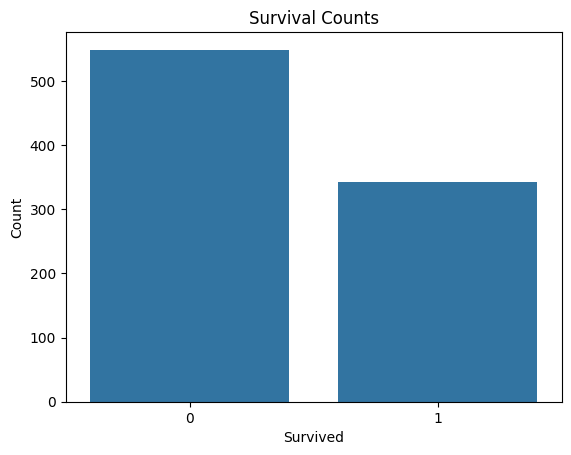

In [5]:
# Bar chart of survived variable using seaborn

sns.countplot(x='Survived', data=df_manual)
plt.title('Survival Counts')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

**Survived plot results**

The bar chart shows:
  - 549 passengers did not survive (0)
  - 342 passengers survived (1)
  - Overall survival rate: ~38.4% (342/891)

This matches historical records: the Titanic had a ~32% historical survival rate, but varies by source and passenger class. The lab data shows a slightly higher rate (~38%), likely because the dataset may oversample or focus on certain passenger classes. The large class imbalance (more deaths than survivals) is notable for machine learning purposes.

**Suitable target variable for supervised learning**

`Survived` is an excellent target/label variable. It is:
  - **Binary** (0 or 1), making it ideal for **classification** problems.
  - **Well-defined**: clear outcome with no ambiguity.
  - **Predictive**: other variables (age, sex, fare, class) are known to correlate with survival, enabling meaningful predictions.

This dataset is naturally suited for **binary classification** tasks (e.g., logistic regression, random forest, SVM) where the goal is to predict whether a passenger survived or not based on their attributes.

In [6]:
# Create age_fill columns
df_manual['age_fill_mean'] = df_manual['Age'].fillna(df_manual['Age'].mean())
df_manual['age_fill_median'] = df_manual['Age'].fillna(df_manual['Age'].median())
df_manual['age_fill_mode'] = df_manual['Age'].fillna(df_manual['Age'].mode()[0])
df_manual[['Age', 'age_fill_mean', 'age_fill_median', 'age_fill_mode']].head(10)

df['age_fill_mean'] = df['Age'].fillna(df['Age'].mean())
df['age_fill_median'] = df['Age'].fillna(df['Age'].median())
df['age_fill_mode'] = df['Age'].fillna(df['Age'].mode()[0])
df[['Age', 'age_fill_mean', 'age_fill_median', 'age_fill_mode']].head(10)

,Age,age_fill_mean,age_fill_median,age_fill_mode
0,22.0,22.000000,22.0,22.0
1,38.0,38.000000,38.0,38.0
2,26.0,26.000000,26.0,26.0
3,35.0,35.000000,35.0,35.0
4,35.0,35.000000,35.0,35.0
5,NaN,29.699118,28.0,24.0
6,54.0,54.000000,54.0,54.0
7,2.0,2.000000,2.0,2.0
8,27.0,27.000000,27.0,27.0
9,14.0,14.000000,14.0,14.0


In [7]:
# Import KNeighborsRegressor
%pip install scikit-learn
from sklearn.neighbors import KNeighborsRegressor

# Divide data into two datasets
data_drop_age_na = df[df['Age'].notna()]
data_age_na = df[df['Age'].isna()]

# Instantiate and fit kNN model
knn = KNeighborsRegressor(n_neighbors=5)
X_train = data_drop_age_na[['SibSp', 'Parch', 'Fare']]
y_train = data_drop_age_na['Age']
knn.fit(X_train, y_train)

# Predict Age for missing values
X_test = data_age_na[['SibSp', 'Parch', 'Fare']]
predicted_ages = knn.predict(X_test)

# Create Age_fill_knn column
df['Age_fill_knn'] = df['Age'].copy()
df.loc[df['Age'].isna(), 'Age_fill_knn'] = predicted_ages

# Display results
df[['Age', 'Age_fill_knn', 'SibSp', 'Parch', 'Fare']].head(10)


"If you put butter and salt on it, it tastes like salty butter."
        -- Popcorn comes to the Discworld
           (Terry Pratchett, Moving Pictures)
Note: you may need to restart the kernel to use updated packages.


,Age,Age_fill_knn,SibSp,Parch,Fare
0,22.0,22.0,1,0,7.2500
1,38.0,38.0,1,0,71.2833
2,26.0,26.0,0,0,7.9250
3,35.0,35.0,1,0,53.1000
4,35.0,35.0,0,0,8.0500
5,NaN,24.2,0,0,8.4583
6,54.0,54.0,0,0,51.8625
7,2.0,2.0,3,1,21.0750
8,27.0,27.0,0,2,11.1333
9,14.0,14.0,1,0,30.0708


In [9]:
# Count missing age values
missing_age_count = df['Age'].isna().sum()
total_passengers = len(df)
print(f"Missing age information: {missing_age_count} out of {total_passengers} passengers ({missing_age_count/total_passengers*100:.1f}%)")

Missing age information: 177 out of 891 passengers (19.9%)


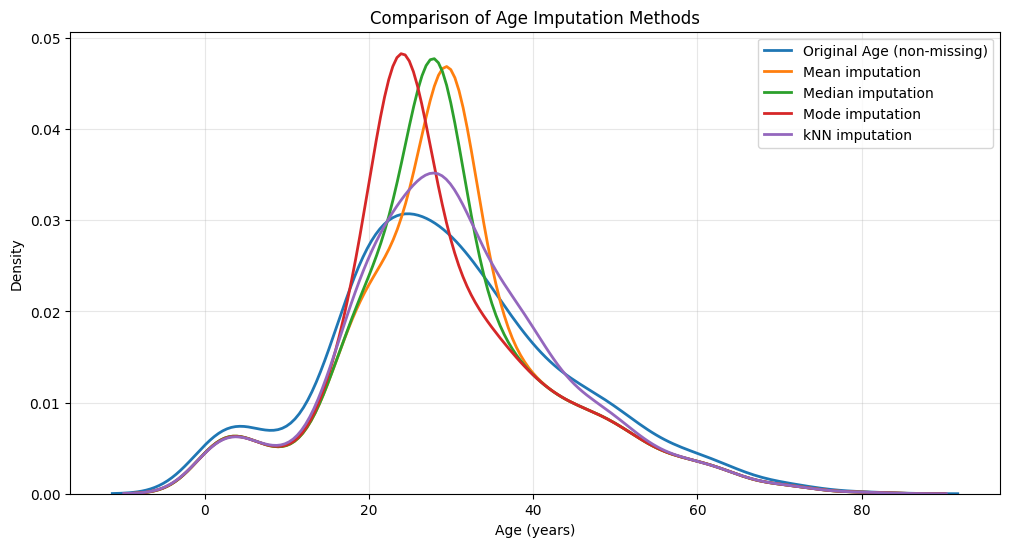

In [10]:
# Create density plots to compare imputation methods
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Plot density for original Age (non-missing values only)
sns.kdeplot(df['Age'].dropna(), label='Original Age (non-missing)', linewidth=2)

# Plot densities for different imputation methods
sns.kdeplot(df['age_fill_mean'], label='Mean imputation', linewidth=2)
sns.kdeplot(df['age_fill_median'], label='Median imputation', linewidth=2)
sns.kdeplot(df['age_fill_mode'], label='Mode imputation', linewidth=2)
sns.kdeplot(df['Age_fill_knn'], label='kNN imputation', linewidth=2)

plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.title('Comparison of Age Imputation Methods')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Missing age information**

177 out of 891 passengers (19.9%) are missing age data.

**kNN algorithm for filling missing values**

The k-Nearest Neighbors approach fills missing ages by:
1. **Splitting the data**: Separating passengers with known ages from those with missing ages.
2. **Selecting features**: Using `SibSp` (siblings/spouses), `Parch` (parents/children), and `Fare` as predictors. These features were chosen because they likely correlate with age (e.g., family size, ticket price).
3. **Training the model**: Fitting a kNN regressor (k=5) on passengers with known ages, learning the relationship between the features and age.
4. **Predicting**: For each passenger with missing age, finding the 5 most similar passengers (based on SibSp, Parch, Fare) and averaging their ages.
5. **Imputing**: Replacing missing ages with the predicted values.

This method is more sophisticated than mean/median/mode because it considers passenger context rather than using a single global statistic.

**Density plot interpretation**

- **X-axis**: Age in years (ranging from ~0 to 80).
- **Y-axis**: Density (probability density, not count). Higher density means more passengers at that age. The area under each curve sums to 1.

**What the plots reveal**:
- **Original Age** (blue): Shows the actual age distribution with a broad peak around 20-40 years, plus a smaller bump around 5-10 years (children).
- **Mean imputation** (orange): Nearly identical to original but slightly smoother. Adds 177 passengers all at age ~29.7 (the mean), creating a subtle spike there.
- **Median imputation** (green): Similar effect but spike at age 28 (the median).
- **Mode imputation** (red): Creates a very sharp, tall spike at age 24 (the mode), since 177 passengers are assigned exactly this value. This distorts the distribution significantly.
- **kNN imputation** (purple): Most similar to the original distribution. The curve is smoother and doesn't show artificial spikes because predicted ages vary based on passenger features, not a single constant.

**Key insight**: Mode imputation creates the most distortion (tall red spike). kNN best preserves the natural shape of the distribution because it produces varied, context-sensitive predictions rather than assigning all missing values to one number.

**Why Cabin wouldn't work well with these methods**

From an **interpretation perspective**, Cabin has fundamentally different missing-value semantics than Age:

- **Age**: Missing age is a data collection problem. Every passenger *had* an age; we just don't know it. Imputation aims to estimate the true unknown value.
  
- **Cabin**: Missing cabin likely means *no cabin was assigned* (many lower-class passengers didn't have cabins). The missingness is informative—it encodes socioeconomic status. 

Imputing cabin numbers (e.g., using kNN to predict "C85" for a missing cabin) would falsely imply those passengers *had* cabins, erasing meaningful information about class differences. The absence itself is the signal. Mean/median/mode don't even make sense for nominal cabin codes. Thus, Cabin missingness should be preserved or encoded as a separate category (e.g., "None"), not filled with guesses.